<a href="https://colab.research.google.com/github/Yuvrajtakk/ml-internship/blob/main/YOLO_family.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The YOLO Family — Brick by Brick, v1 to Present

This notebook builds the entire YOLO (You Only Look Once) object detection lineage from the ground up — starting with YOLOv1 in 2015 and working forward version by version. Instead of handing you finished model code, we'll construct every mechanism piece by piece: one grid cell, one loss term, one architectural change at a time, always tying it back to the classical ML concepts (SVMs, regression, logistic outputs) you already know from your MNIST work. Nothing gets shortcut into a library call until you've built and verified the manual version yourself.

## 🧱 YOLOv1 (2015) — The Grid Foundation

### Concept + Analogy, and Why It Was Needed

**The problem before YOLO existed:**

Before 2015, object detectors worked in two separate stages:
1. **Propose regions** — generate thousands of candidate boxes that *might* contain an object (e.g. Selective Search, or a Region Proposal Network).
2. **Classify each region** — run a full CNN classifier on *each* of those thousands of crops, one at a time, to check "is there an object here, and what is it?"

**The analogy:**

Imagine you're looking for a lost dog in a large park.

- **Old way (R-CNN style):** You have a cardboard tube. You walk the entire park, holding the tube to your eye, checking one small patch of grass after another — thousands of patches — asking "dog here? dog here? dog here?" each time. Thorough, but painfully slow, and each glance has zero awareness of what's happening in the rest of the park.
- **YOLO's way:** You stand on a hill, look at the *entire* park in one glance, mentally overlay a grid on it, and instantly answer for every square at once: "does an object's center fall here, and if so, what are its boundaries?"

**The core idea:** YOLO reframes object detection as a **single regression problem**. One forward pass through one neural network → one output tensor containing all box coordinates and class probabilities simultaneously. No separate proposal stage, no running the network thousands of times per image.

**Why this specific mechanism was necessary (not just "it's better"):**

The two-stage approach broke down in two concrete, measurable ways:
- **Speed:** Running a full CNN forward pass ~2000 times per image (once per proposed region) took seconds per frame — nowhere close to real-time video (which needs ~30 fps, i.e. ~33ms/frame).
- **Context blindness:** Because each region proposal was classified *in isolation*, cropped out of its surroundings, the classifier had no information about the rest of the image. This caused a specific, reproducible failure: background textures (e.g. grass patterns, shadows) frequently got misclassified as objects, because the model had no global scene context to sanity-check against.

**Bridge to what you know:** Your MNIST classifier took one 28×28 image and output one probability vector over 10 digits, in one pass. YOLOv1 does something structurally similar but scaled spatially — instead of one output vector for the whole image, it produces a *grid* of output vectors, one per spatial region, all computed in that same single forward pass.

**📖 Running Glossary:**
- **Grid Cell:** A fixed, pre-defined spatial region of the input image. In YOLOv1, whichever cell an object's center falls into becomes solely responsible for predicting that object.

---

🛑 **Checkpoint:** In your own words — why couldn't the "old way" just be sped up by making the CNN classifier faster? What's the *structural* reason (not just raw speed) that YOLO's single-pass grid approach fixes something the old approach couldn't fix just by optimizing?

Think about what a faster CNN classifier would actually speed up in the old pipeline. The old pipeline was:

Generate ~2000 region proposals (candidate boxes)
Crop each region out of the image
Run the CNN classifier on each of those 2000 crops, one at a time

Question to think about: If you made the CNN itself 10x faster, would step 3 still need to run 2000 separate times per image?
And separately — even if you sped up step 3 to be instant, would that fix the other problem: a classifier looking at a single cropped patch, with no view of anything outside that crop?
Try answering just this narrower piece: does making the classifier faster reduce the number of times it has to run? Yes or no, and why?

Making the CNN faster only speeds up one execution of it. It does nothing to reduce how many times it has to execute. The old pipeline's core bottleneck wasn't "the CNN is slow" — it was "we run a CNN thousands of separate times per single image." Speed up each run by 10x, you still multiply that by 2000 runs. The bottleneck is architectural (repeated execution), not computational (raw speed per run).
That's precisely why YOLO's fix wasn't "build a faster classifier" — it was restructure the problem so the network only runs once per image. One forward pass produces predictions for every region simultaneously, instead of one region at a time.

since the network sees the whole image in that one pass (not a cropped patch), it naturally has global context — it can see grass around the dog rather than judging a tiny cropped square in isolation.

 - Single-pass / single-shot detection: Making the entire image go through the network exactly once to produce all predictions at once, rather than running the network repeatedly on candidate sub-regions.

### The Math, Worked By Hand — One Grid Cell

Let's take the smallest useful example. Imagine an image that's **300×300 pixels**, and we overlay a **3×3 grid** on it (just for this toy example — the real YOLOv1 paper used 7×7, we'll get there).

Since the image is 300×300 and the grid is 3×3, each grid cell covers exactly **100×100 pixels**.

Let's focus on just the **top-left cell** — Row 0, Column 0. It covers:
- x-axis: pixels 0 to 100
- y-axis: pixels 0 to 100

This cell's job: predict whether an object's center falls inside this 100×100 region, and if so, where its box boundaries are.

For this toy example, let's say we only care about 2 classes: 🐕 Dog and 🐈 Cat, and this cell predicts exactly 1 bounding box. That means this single cell outputs an array of exactly **7 numbers**:

| Value | Meaning | Example |
|---|---|---|
| x | box center x, *relative to this cell* (0 to 1) | 0.5 |
| y | box center y, *relative to this cell* (0 to 1) | 0.4 |
| w | box width, *relative to the whole image* (0 to 1) | 0.6 |
| h | box height, *relative to the whole image* (0 to 1) | 0.8 |
| conf | model's confidence an object exists here | 0.85 |
| P(Dog) | probability it's a dog, if object exists | 0.90 |
| P(Cat) | probability it's a cat, if object exists | 0.10 |

**Tensor shape for this one cell's output: `(7,)`** — 1 box × 5 box values (x,y,w,h,conf) + 2 class probabilities.

**Bridge to what you know:** this is like fusing a regression output (the coordinates — similar to predicting a continuous value) with a classification output (the class probabilities — similar to your MNIST softmax) into a single array.

**Checkpoint before we do the arithmetic**: Given that this cell covers pixels 0–100 on both axes, and it predicted x = 0.5, y = 0.4 (remember: these are relative to this cell, not the whole image) — what do you think the actual pixel coordinates of the box's center are on the full 300×300 image? Take a guess at the calculation.
- x: 0 + (0.5 × 100) = 50
- y: 0 + (0.4 × 100) = 40

So the center of this predicted box sits at pixel (50, 40) on the full image.multiplied the relative fraction by the cell's size (100px) rather than dividing — that's the operation that converts "fraction of a local cell" into "absolute pixel position

Now let's do the same for width and height — but there's a twist. Unlike x,y (which are relative to the cell, 100px), w and h are defined relative to the entire image (300px), not the cell. This is a real YOLOv1 design choice — box position is local, box size is global.
We had w = 0.6 and h = 0.8.
🛑 Question: Using the same idea as before (multiply the relative fraction by the size it's relative to) — but this time using the full image size of 300px instead of the cell's 100px — what do you get for the box's width and height in pixels?

- Width: 0.6 × 300 = 180 pixels
- Height: 0.8 × 300 = 240 pixels

So putting it all together: this single grid cell predicted a box centered at (50, 40), that's 180px wide and 240px tall — meaning it spans more than half the entire 300×300 image, even though it was predicted by a tiny 100×100 corner cell. That's the point of separating "where" (local, cell-relative) from "how big" (global, image-relative) — a cell near the edge of the image can still predict a large box that extends well beyond its own boundaries.
📖 Glossary addition:

- x, y (YOLOv1): box center coordinates, relative to the grid cell (0 to 1)
- w, h (YOLOv1): box width/height, relative to the entire image (0 to 1)

### Confidence Score — What It Actually Means

In MNIST work, a confidence score was just "how sure is the model this digit is a 7" — a single number from the softmax.

YOLO's confidence target is stricter. It's not just "how sure," it's mathematically **defined** as:

**Confidence = P(Object) × IoU**

- **P(Object)** is 1 if a real object's center truly falls in this cell (ground truth), 0 if it doesn't.
- **IoU (Intersection over Union)** — a new term — measures how well the *predicted* box overlaps with the *true* box. It's the universal scoring yardstick in object detection: Area of Overlap ÷ Total Combined Area. Ranges 0 (no overlap) to 1 (perfect match).

**📖 Glossary addition:**
 **IoU (Intersection over Union):** Overlap area between two boxes, divided by their combined (union) area. 0 = no overlap, 1 = identical boxes.
🛑 **Let's break this on purpose**, like you'll do throughout this notebook. Imagine two boxes, both 10×10 pixels, sitting side-by-side so their edges are perfectly touching — but with zero overlapping area.
**Question**: what's the Intersection area between them, and what's the Union area? (Union = Area A + Area B − Intersection). 

**Answer**
- Area A = 10×10 = 100
- Area B = 10×10 = 100
- Intersection = 0 (no overlap, just touching)
- Union = 100 + 100 − 0 = 200
- IoU = Intersection ÷ Union = 0 ÷ 200 = 0

And tying this back to the confidence formula from before: Confidence = P(Object) × IoU. Even if an object truly exists here (P(Object) = 1), if the predicted box has zero overlap with the true box, Confidence = 1 × 0 = 0. The model gets fully penalized — finding that an object exists isn't enough; the box has to actually land on it.

### Building IoU From Scratch (No Library Shortcuts)

Before we ever use a library function like `torchvision.ops.box_iou`, we build IoU by hand and prove it works — that's the rule for this notebook.

We'll work with boxes in **corner format**: `[x_min, y_min, x_max, y_max]` — this is easier for area math than the center/width/height format YOLO predicts. (Converting between the two is a simple step we'll add later.)

![alt text](image-1.png)

In [14]:
def compute_iou(box1, box2):
    # box format: [x_min, y_min, x_max, y_max]

    # Step 1: find the coordinates of the overlapping (intersection) rectangle.
    # The left edge of the intersection is the RIGHTMOST of the two left edges.
    x_left = max(box1[0], box2[0])
    # The top edge of the intersection is the BOTTOM-MOST of the two top edges.
    y_top = max(box1[1], box2[1])
    # The right edge of the intersection is the LEFTMOST of the two right edges.
    x_right = min(box1[2], box2[2])
    # The bottom edge of the intersection is the TOP-MOST of the two bottom edges.
    y_bottom = min(box1[3], box2[3])

    # Step 2: compute intersection area.
    # If boxes don't overlap, (x_right - x_left) or (y_bottom - y_top) would be
    # negative — max(0, ...) clamps that to 0 so "negative overlap" can't happen.
    intersection = max(0, x_right - x_left) * max(0, y_bottom - y_top)

    # Step 3: compute the area of each individual box.
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Step 4: union = both areas combined, minus the overlap
    # (so the overlapping region isn't counted twice).
    union = box1_area + box2_area - intersection

    # Step 5: final IoU ratio.
    iou = intersection / union
    return iou


# Test it on our touching-boxes example from before
box_a = [0, 0, 10, 10]   # left box
box_b = [10, 0, 20, 10]  # right box, touching box_a's right edge exactly

result = compute_iou(box_a, box_b)
print(f"IoU of touching boxes: {result}")   # expect 0.0

IoU of touching boxes: 0.0


### Run and Visualize: IoU Across Multiple Cases

Let's test `compute_iou` on 4 different scenarios so you can see the metric behave across the full range, not just the two cleanest examples:
1. **Zero overlap** (far apart — tests our negative-clamping fix)
2. **Partial overlap** (the typical case)
3. **Fully inside** (one box swallowed by the other)
4. **Exact match** (identical boxes)

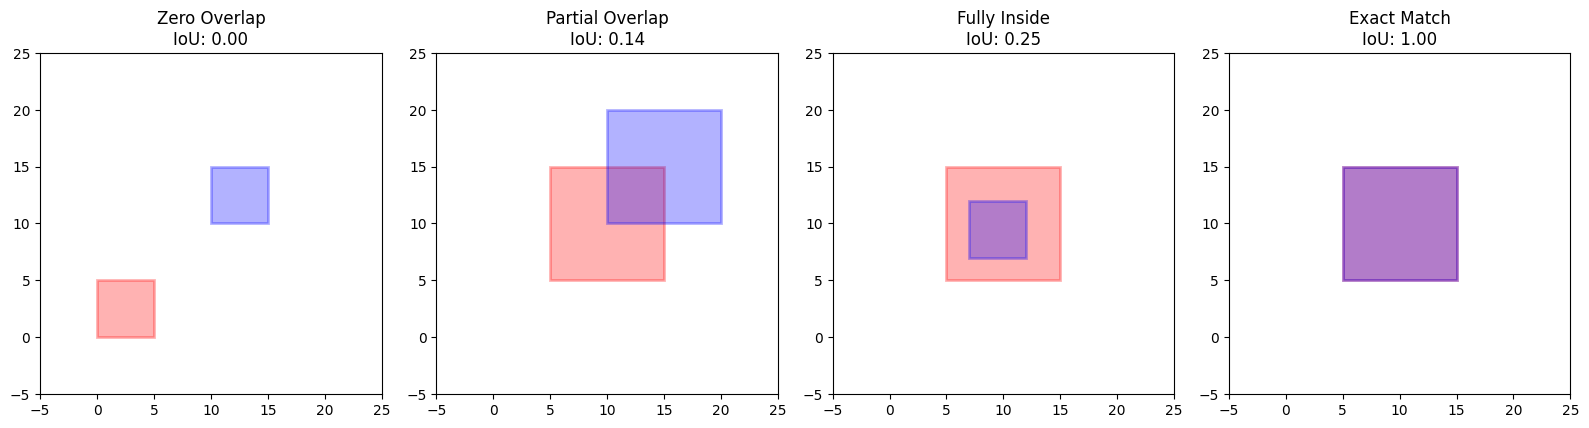

In [15]:
# matplotlib is Python's standard plotting library — we use it to draw
# our boxes visually so you can *see* the overlap, not just read a number.
import matplotlib.pyplot as plt
# patches lets us draw shapes (like rectangles) on top of a matplotlib plot.
import matplotlib.patches as patches

def compute_iou(box1, box2):
    # (same function as before — repeated here so this cell runs standalone)
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])
    intersection = max(0, x_right - x_left) * max(0, y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = box1_area + box2_area - intersection
    # Guard against divide-by-zero if both boxes had zero area
    if union == 0:
        return 0.0
    return intersection / union

def plot_iou_case(ax, box1, box2, title):
    # box format: [x_min, y_min, x_max, y_max]
    # Compute width/height for matplotlib's Rectangle (which needs w,h not x_max,y_max)
    w1, h1 = box1[2] - box1[0], box1[3] - box1[1]
    w2, h2 = box2[2] - box2[0], box2[3] - box2[1]

    # Draw box1 in red, semi-transparent so overlaps are visible
    rect1 = patches.Rectangle((box1[0], box1[1]), w1, h1,
                               linewidth=2, edgecolor='red',
                               facecolor='red', alpha=0.3, label='Box 1')
    # Draw box2 in blue
    rect2 = patches.Rectangle((box2[0], box2[1]), w2, h2,
                               linewidth=2, edgecolor='blue',
                               facecolor='blue', alpha=0.3, label='Box 2')

    ax.add_patch(rect1)
    ax.add_patch(rect2)

    iou = compute_iou(box1, box2)
    ax.set_title(f"{title}\nIoU: {iou:.2f}")
    ax.set_xlim(-5, 25)
    ax.set_ylim(-5, 25)
    ax.set_aspect('equal')  # keep boxes visually undistorted

# Create 1 row, 4 columns of side-by-side plots
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

# Case 1: Zero overlap — boxes far apart diagonally
plot_iou_case(axs[0], [0, 0, 5, 5], [10, 10, 15, 15], "Zero Overlap")

# Case 2: Partial overlap — boxes shifted so they partly overlap
plot_iou_case(axs[1], [5, 5, 15, 15], [10, 10, 20, 20], "Partial Overlap")

# Case 3: Fully inside — box2 entirely contained within box1
plot_iou_case(axs[2], [5, 5, 15, 15], [7, 7, 12, 12], "Fully Inside")

# Case 4: Exact match — identical boxes
plot_iou_case(axs[3], [5, 5, 15, 15], [5, 5, 15, 15], "Exact Match")

plt.tight_layout()
plt.show()

### Architecture: The Real YOLOv1 Output Tensor

We used a toy 3×3 grid with 1 box and 2 classes so far. The actual YOLOv1 paper used:

- A **7×7** grid over the image (49 cells total)
- **2** bounding boxes predicted per cell (giving each cell a chance to predict, e.g., one wide box and one tall box — though both boxes share the same class prediction)
- **20** classes (from the PASCAL VOC dataset the paper used)

So each of the 49 cells outputs an array structured as:

`[Box1_x, Box1_y, Box1_w, Box1_h, Box1_conf, Box2_x, Box2_y, Box2_w, Box2_h, Box2_conf, Class1_prob, ..., Class20_prob]`

That's `5 + 5 + 20 = 30` numbers per cell.

Since there are 49 cells (7×7), the **entire network's final output is one tensor of shape `(7, 7, 30)`**.

**The backbone (feature extractor):**
- Input: a `(448, 448, 3)` image (Height, Width, RGB channels)
- 24 convolutional layers compress the image spatially while extracting visual patterns (edges → textures → shapes → object parts)
- 2 fully-connected (dense) layers at the end — similar to the final layer of your MNIST classifier, but here it outputs `7×7×30 = 14,700` numbers instead of 10
- That flat 14,700-number vector then gets **reshaped** into the `(7,7,30)` grid tensor

**Old way vs. YOLOv1, side by side:**

| Feature | Old Way (Sliding Window / R-CNN) | YOLOv1 |
|---|---|---|
| Pipeline | Propose ~2000 regions → crop → run CNN 2000× | Pass whole image through CNN **once** → get `(7,7,30)` output |
| Speed | Seconds per frame | ~45 frames per second (real-time) |
| Context | Only sees isolated crops | Sees the whole image at once |

In [1]:
# torch is PyTorch, the deep learning library we'll use throughout this notebook.
import torch

# --- Architectural constants for YOLOv1 ---
S = 7   # Grid size: image divided into a 7x7 grid of cells
B = 2   # Number of bounding boxes predicted per cell
C = 20  # Number of object classes (PASCAL VOC dataset)

# Each cell predicts (B * 5) box values + C class probabilities
values_per_cell = (B * 5) + C   # (2 * 5) + 20 = 30

# Simulate a batch of 4 images passing through the network.
# In real training you'd have actual images; here we just want to see the SHAPES.
batch_size = 4

# torch.randn(shape) creates a tensor filled with random numbers
# (sampled from a normal distribution) — we use it to simulate the network's
# raw, untrained output before we've built the real CNN layers.
# Shape: (batch_size, S*S*values_per_cell) = (4, 49*30) = (4, 1470)
raw_output = torch.randn(batch_size, S * S * values_per_cell)
print(f"Raw flat output shape: {raw_output.shape}")

# .view() reshapes a tensor WITHOUT changing the underlying data —
# it's just a different "window" onto the same numbers in memory.
# We reshape the flat (4, 1470) vector into (4, 7, 7, 30):
# dimensions mean (Batch, Grid_Row, Grid_Column, Cell_Predictions)
yolo_output = raw_output.view(batch_size, S, S, values_per_cell)
print(f"Reshaped grid tensor shape: {yolo_output.shape}")

# Let's pull out ONE cell's prediction: image 0, row 3, column 4 (near center)
one_cell = yolo_output[0, 3, 4, :]
print(f"Single cell prediction shape: {one_cell.shape}")  # should be (30,)

Raw flat output shape: torch.Size([4, 1470])
Reshaped grid tensor shape: torch.Size([4, 7, 7, 30])
Single cell prediction shape: torch.Size([30])
